In [1]:
library(Seurat)
library(scop)
library(Signac)
library(ggplot2)
set.seed(4180)
setwd("/")
#########color
cols <- c("#444576", "#4682B4",
 "#AEDEEE","#FFA500",
 "#FFD790","#C65762","#FBDFDE",
 "#F6EFCF","#BCB99F")
pal <- colorRampPalette(cols)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




Registered S3 method overwritten by 'scop':
  method             from  
  FoldChange.default Seurat

          ⬢          .        ⬡             ⬢     .
                     _____ _________  ____
                    / ___// ___/ __ ./ __ .
                   (__  )/ /__/ /_/ / /_/ /
                  /____/ .___/.____/ .___/
                                  /_/
      ⬢               .      ⬡        .          ⬢

------------------------------------------------------------
Version: 0.8.7 (2026-03-31 update)
Website: https://mengxu98.github.io/scop/

Python environment initialization is disabled
To enable it, set: options(scop_env_init = TRUE)

The message can be suppressed by: 
  suppressPackageStartupMessages(library(scop))
  or options(log_message.verbose = FALSE)
------------------------------------------------------------



ERROR: Error in setwd("/home/ly/work/YF/mHeart/"): cannot change working directory


In [2]:
subsc.list <- readRDS("data/subsc.list.Rds")
names(subsc.list)

[1] "aCM"        "FB"         "EC"         "EndoCC"     "LEC"       
 [6] "SMC"        "Pericyte"   "Adipocyte"  "Neuronal"   "T"         
[11] "B"          "Macrophage" "DC"

In [3]:
FB <- subsc.list[[2]]
FB[["ATAC"]] <- readRDS("data/mHeart_ATAC.Rds")[,colnames(FB)][['ATAC']]
FB[["activity"]] <- readRDS("data/activity.Rds")[,colnames(FB)][['activity']]

In [14]:
FB <- FindClusters(FB, resolution = 0.2)
FB$subtype <- paste("FB", "-",
 as.numeric(FB$seurat_clusters),
 sep = ""
 )
FB$subtype <- factor(FB$subtype, levels = paste("FB",
 sort(unique(as.numeric(FB$seurat_clusters))),
 sep = "-"
 ))

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 21551
Number of edges: 549235

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8711
Number of communities: 4
Elapsed time: 3 seconds


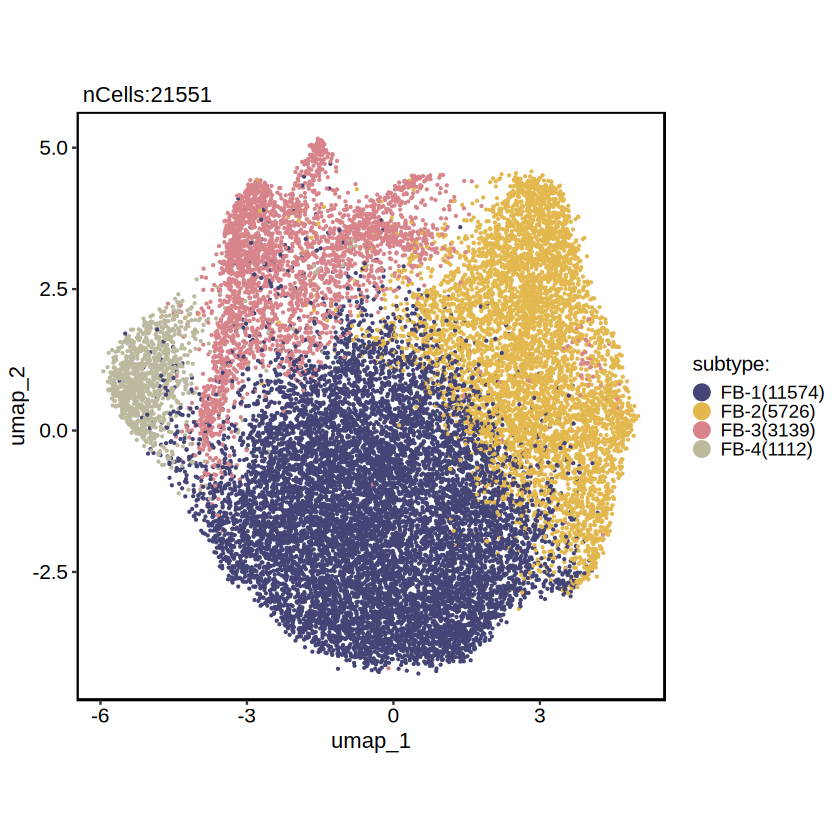

In [15]:
# fig4a
p <- CellDimPlot(
 srt = FB, group.by = "subtype",
 legend.position = "right", label_repel = T,
 label_point_size = 0.1, reduction = "umap",
 label = F, label_insitu = T,
 theme_use = "theme_scop",
 palcolor = pal(4), raster = F,
 label.fg = "black", label.bg = "grey95",
 label.bg.r = 0
)
ggsave(
 plot = p, filename = "fig4a_umap.pdf", path = "plot/figure4/",
 create.dir = TRUE, width = 4, height = 4
)
p

In [16]:
# fig4b
library(ComplexHeatmap)
library(dplyr)
DefaultAssay(FB) <- "RNA"
FB <- RunDEtest(FB,
 group.by = "subtype", fc.threshold = 1.2, cores = 4,
 assay = "RNA", only.pos = T, min.pct = 0.25
)
AllMarkers <- filter(
 FB@tools$DEtest_subtype$AllMarkers_wilcox,
 p_val_adj < 0.05,
 test_group_number == 1
)
AllMarkers <- AllMarkers %>%
 filter(p_val_adj < 0.05) %>%
 group_by(group1) %>%
 arrange(desc(avg_log2FC)) %>%
 slice_head(n = 50)
AllMarkers$label <- rownames(AllMarkers)
result <- AllMarkers %>%
 filter(p_val_adj < 0.05) %>%
 group_by(group1) %>%
 arrange(desc(avg_log2FC)) %>%
 slice_head(n = 5)
ave.dt <- scale(
 t(as.matrix(AverageExpression(FB[AllMarkers$gene, ],
 group.by = "subtype", assays = "RNA", layer = "data"
)$RNA)))
ave.dt <- ave.dt[, AllMarkers$gene]
ha <- HeatmapAnnotation(foo = anno_mark(
 at = as.numeric(result$label),
 labels = result$gene,
 labels_gp = gpar(fontsize = 10, rot = 45, fontface = "italic")
))
pdf("plot/figure4/fig4b_FBsubtype_markers.pdf", width = 6, height = 3) # save as pdf file
draw(Heatmap(ave.dt,
 cluster_columns = F,
 cluster_rows = F, col = c("grey80", "white", "#444576"),
 show_column_names = F,
 heatmap_legend_param = list(
 title = "Expression", at = c(-2, 0, 2),
 labels = c("Min", "", "Max")
 ),
 top_annotation = ha, row_names_side = "left",
 width = unit(10, "cm"), height = unit(4, "cm")
))
dev.off()

Loading required package: grid

ComplexHeatmap version 2.26.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




ℹ [2026-05-07 23:44:06] Data type is log-normalized

ℹ [2026-05-07 23:44:06] Start differential expression test

ℹ [2026-05-07 23:44:06] Find all markers(wilcox) among [1] 4 groups...

ℹ [2026-05-07 23:44:06] Using 4 cores

⠙ [2026-05-07 23:44:06] Running for FB-1... [1/4] ■■          25% | ETA:  8s

⠹ [2026-05-07 23:44:06] Running for FB-2... [2/4] ■■■■■       50% | ETA:  5s

✔ [2026-05-07 23:44:06] Completed 4 tasks in 8.5s



ℹ [2026-05-07 23:44:06] Building results

✔ [2026-05-07 23:44:14] Differential expression test completed

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.


agg_record_5a24acc27a17 
                      2

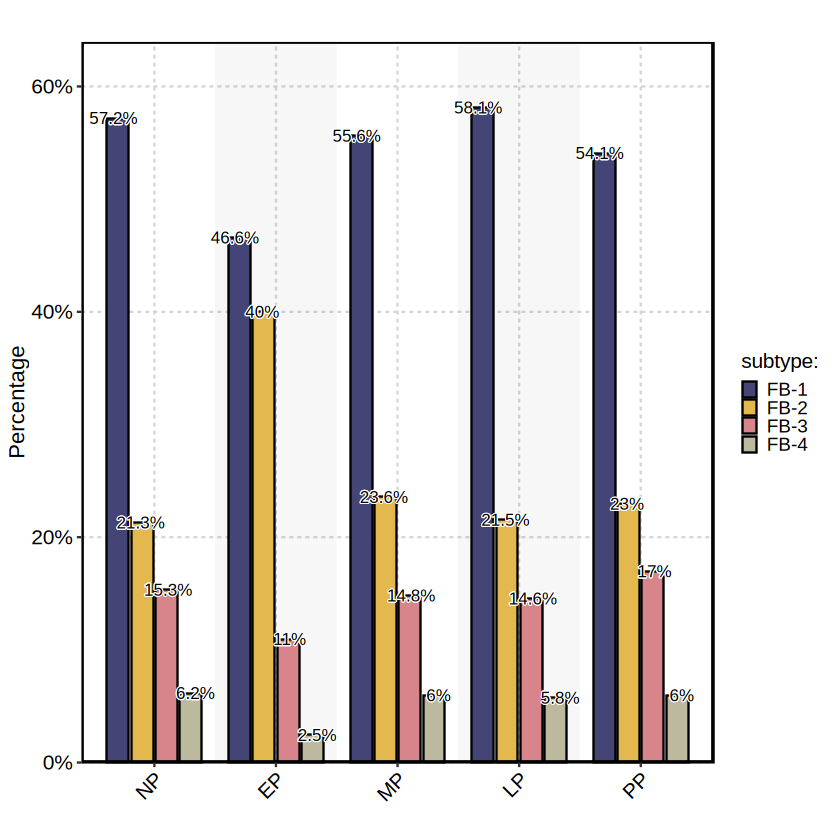

In [17]:
#fig4c
p <- CellStatPlot(FB, stat.by = "subtype", group.by = "group",
 label = T,palcolor = pal(4),position ="dodge",
 plot_type = "bar",xlab = '',ylab = 'Percentage')
p 
ggsave(plot = p,filename = "fig4c_FBstat.pdf",path = "plot/figure4/",
 create.dir = TRUE,width = 6,height = 3)

In [18]:
# fig4e
library(dplyr)
library(patchwork)
library(clusterProfiler)
samplegroup <- c("NP", "EP", "MP", "LP", "PP")
FB <- RunDEtest(FB, group.by = "subtype", only.pos = FALSE, fc.threshold = 1,min.pct = 0.1)
DEGs_group <- FB@tools$DEtest_subtype$AllMarkers_wilcox
allmarker <- DEGs_group %>%
 filter(p_val_adj < 0.05) %>%
 filter(pct.1 > 0.1) %>%
 filter(avg_log2FC > log2(1.5))
df_sig <- subset(allmarker)
group <- data.frame(
 gene = df_sig$gene,
 group = df_sig$group1
)
Gene_ID <- bitr(group$gene,
 fromType = "SYMBOL",
 toType = "ENTREZID",
 OrgDb = "org.Mm.eg.db"
)
data <- merge(Gene_ID, group, by.x = "SYMBOL", by.y = "gene")
levels(data$group) <- c('FB-1','FB-2','FB-3','FB-4','FB-5')
data_GO <- compareCluster(
 ENTREZID ~ group,
 data = data,
 fun = "enrichGO",
 OrgDb = "org.Mm.eg.db",
 ont = "BP",
 pAdjustMethod = "BH",
 pvalueCutoff = 0.05,
 qvalueCutoff = 0.05
)
res <- data_GO@compareClusterResult
for (i in 1:dim(res)[1]) {
 arr <- unlist(strsplit(as.character(res[i, "geneID"]), split = "/"))
 gene_names <- paste(unique(data$SYMBOL[data$ENTREZID %in% arr]), collapse = "/")
 res[i, "geneID"] <- gene_names
}
writexl::write_xlsx(res, "plot/figure4/fig4e_FB_subtype_GO.xlsx")



clusterProfiler v4.18.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

S Xu, E Hu, Y Cai, Z Xie, X Luo, L Zhan, W Tang, Q Wang, B Liu, R Wang,
W Xie, T Wu, L Xie, G Yu. Using clusterProfiler to characterize
multiomics data. Nature Protocols. 2024, 19(11):3292-3320


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter


ℹ [2026-05-07 23:44:35] Data type is log-normalized

ℹ [2026-05-07 23:44:35] Start differential expression test

ℹ [2026-05-07 23:44:35] Find all markers(wilcox) among [1] 4 groups...

ℹ [2026-05-07 23:44:35] Using 1 core

⠙ [2026-05-07 23:44:35] Running for FB-1 [1/4] ■■          25% | ETA: 14s

⠹ [2026-05-07 23:44:35] Running for FB-2 [2/4] ■■■■■       50% | ETA:  9s

⠸ [2026-05-07 23:44:35] Running for FB-3 [3/4] ■■■■■■■     75% | ETA:  5s

✔ [2026-05-07 23:44:35] Completed 4 tasks in 19.8s



ℹ [2026-05-07 23:44:35] Building results

✔ [2026-05-07 23:44:55] Differential expressio


FB-1 FB-2 FB-3 FB-4 
   3    3    3    3 

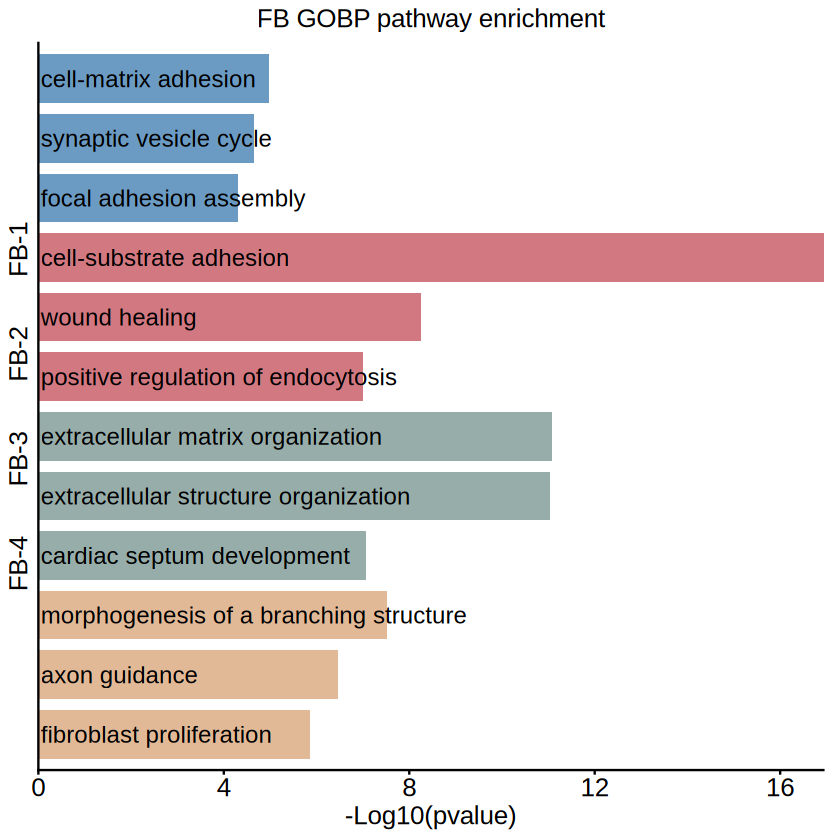

In [20]:
# plot
enrich <- subset(res, Description %in% c(
 "cell-matrix adhesion",
 "synaptic vesicle cycle",
 "focal adhesion assembly"
) & group %in% "FB-1")
enrich <- rbind(enrich, subset(res, Description %in% c(
 "cell-substrate adhesion",
 "positive regulation of endocytosis",
 "wound healing"
) & group %in% "FB-2"))
enrich <- rbind(enrich, subset(res, Description %in% c(
 "extracellular matrix organization",
 "cardiac septum development",
 "extracellular structure organization"
) & group %in% "FB-3"))
enrich <- rbind(enrich, subset(res, Description %in% c(
 "morphogenesis of a branching structure",
 "fibroblast proliferation",
 "axon guidance"
) & group %in% "FB-4"))
colnames(enrich) <- gsub("Groups", "Cluster", colnames(enrich))
dt <- enrich
dt$order <- gsub('FB-1','1',dt$Cluster)
dt$order <- gsub('FB-2','2',dt$order)
dt$order <- gsub('FB-3','3',dt$order)
dt$order <- gsub('FB-4','4',dt$order)
dt <- dt[order(dt$pvalue), ]
dt <- dt[order(dt$order, decreasing = F), ]
table(dt$Cluster)
cols <- c("#4682B4", "#C65762", "#7C9895", "#DAA87C", "#F4EBD0")
pal <- colorRampPalette(cols)
# plot
dt$color <- factor(c(
 rep(pal(4)[3], each = 3),
 rep(pal(4)[2], each = 3),
 rep(pal(4)[1], each = 3),
 rep(pal(4)[4], each = 3)
), levels = pal(5))
dt$Description <- factor(dt$Description, levels = dt$Description)
dt$geneID <- paste(substr(dt$geneID, start = 1, stop = 40), "...", sep = "")
mytheme <- theme(
 axis.title = element_text(size = 15),
 axis.text = element_text(size = 15),
 axis.text.y = element_blank(), # remove y-axis pathway labels in the custom theme:
 axis.ticks.length.y = unit(0, "cm"),
 plot.title = element_text(size = 15, hjust = 0.5),
 legend.title = element_text(size = 13),
 legend.text = element_text(size = 11),
 plot.margin = margin(t = 5.5, r = 10, l = 5.5, b = 5.5)
)
p <- ggplot(data = dt, aes(
 x = -log10(pvalue),
 y = rev(Description),
 fill = Cluster
)) +
 scale_fill_manual(values = pal(5)) +
 geom_bar(stat = "identity", width = 0.8, alpha = 0.8) +
 scale_x_continuous(expand = c(0, 0)) + # align bar bottoms flush with the y-axis
 labs(
 x = "-Log10(pvalue)", y = " FB-4 FB-3 FB-2 FB-1 ",
 title = "FB GOBP pathway enrichment"
 ) +
 # x = 0.61 numeric vector controlling the start position of text labels
 geom_text(
 size = 5,
 aes(x = 0.05, label = Description), hjust = 0
 ) + # hjust = 0,left-aligned
 theme_classic() +
 mytheme +
 NoLegend()
ggsave("plot/figure4/fig4d.pdf",p ,width = 5,height = 5)
p

`normalized_counts` is not a matrix, converting now.



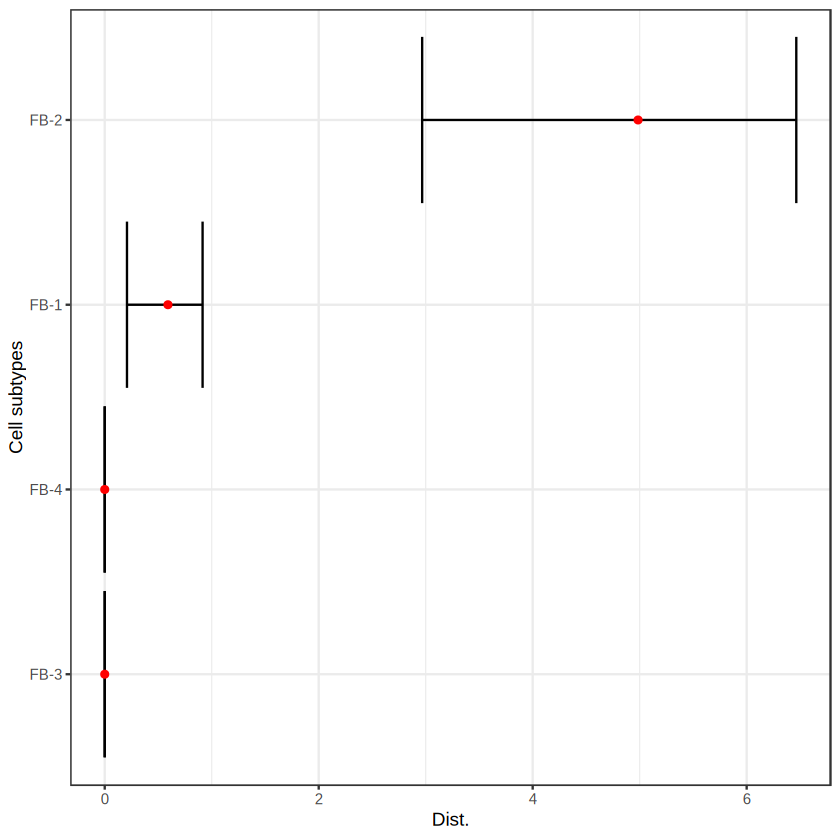

In [25]:
#fig4e
#scDist analysis
library(dplyr)
library(scDist)
library(ggplot2)
library(ggpubr)
######run Dist#################
sim <- list(Y=FB@assays$RNA$scale.data %>% as.data.frame(),
 meta.data=FB@meta.data %>% as.data.frame())
out <- scDist(normalized_counts = sim$Y,
 meta.data = sim$meta.data,
 d = 20, # PCA
 fixed.effects = "group", #stim
 random.effects = c('orig.ident'), #batch/sample
 clusters="subtype" #
)
#plot scDist
p <- DistPlot(out)+theme_bw()+xlab(label = 'Cell subtypes')
p
ggsave("plot/figure4/fig4e_scDist.pdf", p, width = 3, height = 2.5 )

In [26]:
#fig3f
library(dplyr)
samplegroup <-c('NP', 'EP', 'MP', 'LP', 'PP')
DEGs_group <- data.frame()
obj <- subset(FB,subtype %in% "FB-2")
 for (j in 2:5){
 obj<- RunDEtest(srt = obj, group.by = "group",
 assay = 'ATAC',layer = 'counts',
 fc.threshold = 1.5, only.pos = FALSE, min.pct = 0.1,
 group1 = samplegroup[j],group2 = 'NP')
 DEGs_group <- rbind(DEGs_group,obj@tools$DEtest_custom$AllMarkers_wilcox)
 }
DEGs_group$col <- ifelse(DEGs_group$avg_log2FC>0,'up','down')
DEG_dt <- DEGs_group %>%
 group_by(group1, col) %>%
 summarise(count = n())
DEG_dt$count_adjusted <- ifelse(DEG_dt$col == "down", -DEG_dt$count, DEG_dt$count)
DEG_dt$col <- factor(DEG_dt$col, levels = c("up", "down"))
p<-ggplot(DEG_dt, aes(x = group1, y = count_adjusted, fill = col)) +
 geom_bar(stat = "identity", width = 0.8) +
 scale_fill_manual(values = rev(pal(4)[1:2])) + # colorsmust match up/down match
 geom_text(aes(label = count), # show raw value (non-negative)
 vjust = ifelse(DEG_dt$col == "up", -0.5, 1.2), # adjust text position
 color = "black", size = 3) +
 labs(
 title = "",
 x = "",
 y = "Number of differential peaks (.vs NP)",
 fill=''
 ) +
 theme_minimal() +
 theme(
 legend.position = 'right',
 panel.grid.major = element_blank(),
 panel.grid.minor = element_blank(),
 axis.line = element_line(color = "black"),
 axis.ticks = element_line(color = "black"),
 axis.text.x = element_text(angle = 0, hjust = 0.5)
 ) +
 scale_x_discrete(expand = c(0, 0)) +
 scale_y_continuous(
 expand = c(0, 0),
 limits = c(min(DEG_dt$count_adjusted ) - 2000, max(DEG_dt$count) + 2000), # symmetric range
 labels = abs # yaxis labels show absolute values
 )
ggsave(plot = p, filename = "fig4f.pdf",path = "plot/figure4/", width = 3.5, height = 3)

ℹ [2026-05-08 00:02:10] Data type is raw counts

ℹ [2026-05-08 00:02:10] Start differential expression test

ℹ [2026-05-08 00:02:10] Find all markers(wilcox) for custom cell groups...

✔ [2026-05-08 00:02:11] Differential expression test completed

ℹ [2026-05-08 00:02:12] Data type is raw counts

ℹ [2026-05-08 00:02:12] Start differential expression test

ℹ [2026-05-08 00:02:12] Find all markers(wilcox) for custom cell groups...

✔ [2026-05-08 00:02:13] Differential expression test completed

ℹ [2026-05-08 00:02:15] Data type is raw counts

ℹ [2026-05-08 00:02:15] Start differential expression test

ℹ [2026-05-08 00:02:15] Find all markers(wilcox) for custom cell groups...

✔ [2026-05-08 00:02:16] Differential expression test completed

ℹ [2026-05-08 00:02:17] Data type is raw counts

ℹ [2026-05-08 00:02:17] Start differential expression test

ℹ [2026-05-08 00:02:17] Find all markers(wilcox) for custom cell groups...

✔ [2026-05-08 00:02:18] Differential expression test completed

`sum

In [27]:
#fig4g
rna.dt <- AggregateExpression(FB, assays = 'RNA',group.by = 'subtype')[[1]]
act.dt <- AggregateExpression(FB, assays = 'activity',group.by = 'subtype')[[1]]
genes.dt <- intersect(row.names(rna.dt),row.names(act.dt))
p.dt <- data.frame(rna = rowSums(rna.dt[genes.dt,]),activities = rowSums(act.dt[genes.dt,]))
cor_value <- cor.test(log10(p.dt$rna + 1), log10(p.dt$activities + 1))
r <- round(cor_value$estimate, 3)
p_value <- scales::pvalue(cor_value$p.value)
p<-ggplot(data = p.dt, mapping = aes(x = log10(rna+1), y = log10(activities+1))) +
 geom_point(color='gray80', size=0.1) +
 geom_smooth(method = "lm", color = "#4682B4", formula = y ~ x) + # add linear regression line
 theme_light() +
 theme(
 panel.grid.major = element_blank(),
 panel.grid.minor = element_blank(),
 axis.line = element_line(color = "black"),
 legend.position = 'none'
 ) +
 xlab('Normalized RNA counts') + # fix axis label
 ylab('Normalized gene activities') +
 annotate("text", 
 x = Inf, y = 0, # place text in upper-right corner
 label = paste0("r = ", r, "\n", "p = ", p_value), 
 hjust = 1.1, vjust = 0.1, # fine-tune text position
 size = 4, color = "black")
ggsave(plot = p, filename = "fig4g.pdf",path = "plot/figure4/", width = 3, height = 3)

Ranking TFs by mean regulation score across all DORCs ..


Warning message in geom_bar(size = 0.1, stat = "identity", fill = "darkorange", :
“Ignoring unknown parameters: `size`”


Motif,Score,TF
<fct>,<dbl>,<chr>
Klf4,0.29754598,Klf4
Creb5,0.28401606,Creb5
Prox2,0.28227532,
Pou6f1,0.18486503,
Klf3,0.16365112,Klf3
Sox7,0.15814078,
Mbd2,0.13162511,
Zfp276,0.12771739,
Jdp2,0.12430818,


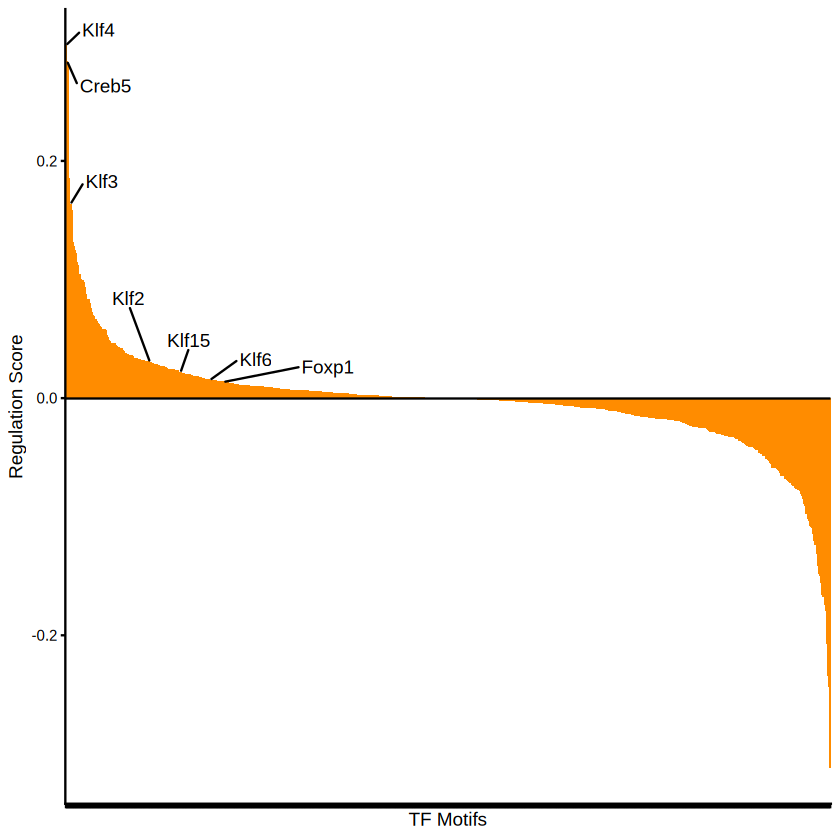

In [12]:
#fig3h
library(ggraph)
library(tidygraph)
library(igraph)
library(ggplot2)
library(FigR)
library(dplyr)
figR.d <- readRDS("data/FB2_figR.rds")
rank.p <- rankDrivers(figR.d,rankBy = "meanScore",myLabels = c("Creb5",'Klf4','Klf2','Klf3',"Klf6","Foxp1","Klf15"))
rank <- rank.p@data
rank.p$data$TF <- ""
p <- rank.p + ggrepel::geom_text_repel(
 aes(label = TF),
 rank,
 max.overlaps = 200,
 box.padding = 0.6,
 min.segment.length = 0.5,
 ylim = c(0.005, NA),
 force = T
)
p
ggsave(plot = p, filename = "fig4h.pdf",path = "plot/figure4/", width = 3.5, height = 3)
rank

In [9]:
library(Hmisc)
library(Signac)
library(FigR)
library(BSgenome.Mmusculus.UCSC.mm10)
library(BiocParallel)
obj <- subset(subsc.list[[2]],subtype %in% c("FB-2"))
obj[["aUCell"]] <- readRDS("data/ac_AUCell.Rds")[,colnames(obj)][["AUCell"]]
obj[["motif"]] <- readRDS("data/motif.Rds")[,colnames(obj)][["motif"]]
DefaultAssay(obj) <- 'motif'
ranklist <- rankDrivers(figR.d,rankBy = "meanScore")$data
rownames(ranklist) <- ranklist$Motif
DefaultAssay(obj) <- 'aUCell'
obj[["aUCell"]] <- as(obj[["aUCell"]],Class = "Assay5")
rownames(obj) <- tolower(gsub("-", " ", gsub("GOBP-", "", rownames(obj))))

Ranking TFs by mean regulation score across all DORCs ..


Warning message in geom_bar(size = 0.1, stat = "identity", fill = "darkorange", :
“Ignoring unknown parameters: `size`”
Warning message:
“Setting row names on a tibble is deprecated.”
Warning message:
“Assay aUCell changing from Assay to Assay5”
Warning message:
“Renaming features in v3/v4 assays is not supported”


In [14]:
#fig4i
dt <- data.frame(t(GetAssayData(obj,assay = 'motif',layer = 'data')[ranklist$Motif,]),
 cardiac = GetAssayData(obj,assay = 'aUCell',layer = 'data')['extracellular matrix assembly',])
res <- rcorr(as.matrix(dt),type	= 'pearson')
res_p <- res$P
plot.dt <- data.frame(score = ranklist[colnames(dt),]$Score,cor_r= res$r[,'cardiac'],genes = colnames(dt) )
plot.dt$color <- ifelse(plot.dt$genes %in% c("Klf4"),'ERR','Others')
esrra_data<- subset(plot.dt, genes %in% c("Klf4", "Klf3", "Klf2","Creb5"))
p <- ggplot(data = plot.dt, mapping = aes(x = score, y = cor_r, color = color)) +
 geom_point(aes(alpha = 0.5)) +
 xlim(-0.35, 0.35) +
 ylim(-0.4, 0.4) +
 theme_light() +
 geom_text_repel(
 data = esrra_data, # subset data
 aes(label = genes), # label content
 color = "black", # labelcolors(distinct from points)
 nudge_x = 0.02, # horizontal offset
 nudge_y = 0.02, # vertical offset
 size = 4,)+
 scale_color_manual(values = c('#C65762','#444576')) +
 theme(
 panel.grid.major = element_blank(), # remove major gridlines
 panel.grid.minor = element_blank(), # remove minor gridlines
 axis.line = element_line(color = "black"),
 legend.position = 'None') +
 xlab('Regulation score')+ylab('Pearson correlation coefficient \n (Motif activities vs extracellular matrix assembly)')
ggsave(plot = p, filename = "fig4i.pdf",path = "plot/figure4/", width = 4.5, height =4,create.dir = T) 

Warning message:
“Removed 191 rows containing missing values or values outside the scale range
(`geom_point()`).”


In [19]:
#fig4j
dt <- data.frame(t(GetAssayData(obj,assay = 'motif',layer = 'data')[ranklist$Motif,]),
 cardiac = GetAssayData(obj,assay = 'aUCell',layer = 'data')['collagen biosynthetic process',])
res <- rcorr(as.matrix(dt),type	= 'pearson')
res_p <- res$P
plot.dt <- data.frame(score = ranklist[colnames(dt),]$Score,cor_r= res$r[,'cardiac'],genes = colnames(dt) )
plot.dt$color <- ifelse(plot.dt$genes %in% c("Klf4"),'ERR','Others')
esrra_data<- subset(plot.dt, genes %in% c("Klf4", "Klf3", "Klf2","Creb5"))
p <- ggplot(data = plot.dt, mapping = aes(x = score, y = cor_r, color = color)) +
 geom_point(aes(alpha = 0.5)) +
 xlim(-0.35, 0.35) +
 ylim(-0.35, 0.35) +
 theme_light() +
 geom_text_repel(
 data = esrra_data, # subset data
 aes(label = genes), # label content
 color = "black", # labelcolors(distinct from points)
 nudge_x = 0.02, # horizontal offset
 nudge_y = 0.02, # vertical offset
 size = 4,)+
 scale_color_manual(values = c('#C65762','#444576')) +
 theme(
 panel.grid.major = element_blank(), # remove major gridlines
 panel.grid.minor = element_blank(), # remove minor gridlines
 axis.line = element_line(color = "black"),
 legend.position = 'None') +
 xlab('Regulation score')+ylab('Pearson correlation coefficient \n (Motif activities vs collagen biosynthetic process)')
ggsave(plot = p, filename = "fig4j.pdf",path = "plot/figure4/", width = 4.5, height =4,create.dir = T) 

Warning message:
“Removed 191 rows containing missing values or values outside the scale range
(`geom_point()`).”


In [28]:
#fig4o
p1 <- FeatureDimPlot(FB,features = c("Clip1","Comp","Chad"),split.by = 'group',ncol = 5,theme_use = "theme_blank")
ggsave(
 plot = p1, filename = "fig4o.pdf", path = "plot/figure4/",
 create.dir = TRUE, width = 12, height = 8
)

In [29]:
#fig4p
p1 <- FeatureDimPlot(FB,features = c("Acta2","Postn","Clip1"),split.by = 'group',ncol = 5,theme_use = "theme_blank")
ggsave(
 plot = p1, filename = "fig4p.pdf", path = "plot/figure4/",
 create.dir = TRUE, width = 12, height = 8
)